# Analytic design ceiling — one problem

How much can shot *allocation* be worth, at most, holding the total number of shots fixed?
Answered **without running a single GST fit**: no data, no sampling, no optimizer.

The Fisher information is an expectation over data and has a closed form, so it comes straight
from the model:

    A_s = sum_beta (grad p_{s,beta})(grad p_{s,beta})^T / p_{s,beta}   (per shot of circuit s)
    H(rho) = sum_s rho_s A_s                                          (rho_s = shots on s)

Cramer-Rao bounds the estimator covariance by `H^-1`, so a bigger `H` is strictly better.
Compare the best possible allocation against uniform at the same budget:

    c = (det H_opt / det H_unif)^(1/r)

The r-th root matters: doubling the budget doubles every `rho_s`, so `det H` picks up `2^r`.
Taking the root makes the quantity linear in shots, so `c` reads as a **shot multiplier** --
the optimal design at N shots carries as much information as uniform at `c*N`.

**Three things this calculation gets wrong if you are not careful.**

1. *It must be evaluated at the TRUE parameters,* or it is not an oracle bound. The truth is
   synthetic and known exactly here, and converts into the fit's parameterization to ~2e-15.
2. *GST has gauge freedom,* so `H` is singular and `det H` is exactly zero. Working with the
   pseudo-determinant makes plain D-optimality ill-posed if the design may be rank-deficient:
   a rank-3 product of 3 eigenvalues beats a rank-40 product containing 37 tiny ones. Given
   `H0 = ridge`, Frank-Wolfe exploits precisely that and dumps the whole budget on 3 circuits.
   Fix: give the oracle the same small uniform identifiability baseline the real method has.
3. *The retained rank is unstable* near the cutoff, so each design's own pseudo-determinant is
   not comparable. Fix: compare both designs inside ONE fixed subspace.

**What it does not bound.** `c` is the ceiling for log-det, the criterion the allocator
optimizes. It is *not* an upper bound on infidelity, which weights directions by a metric `M`
rather than equally. Measured infidelity tracked this prediction well in shape but sat ~1.4x
off in level.

In [25]:
import json
import sys
import time
from pathlib import Path

import numpy as np

SSE = Path.cwd()                                  # run from seed_sweep_experiments
sys.path.insert(0, str(SSE))
sys.path.insert(0, str(SSE.parent))               # GST_POUNDERS, for adaptive_shots

from gst_seed_experiment import (ExperimentConfig, GSTProblem, _make_parameterized_model,
                                 _dense)
import adaptive_shots as ashots

# ---- the problem ---------------------------------------------------------------------
CONFIG = SSE / "all_methods_comparison_6000" / "seed_000101" / "lm" / "config.json"
SEED = 101
N_SHOTS = 4_835_278         # total circuit-shots, matched to what the sweep actually spent
BASELINE_FRAC = 0.05        # uniform baseline for identifiability (see note 2 above)
FW_ITERS = 2000             # 200 (the allocator default) is not converged for a one-shot
                            # allocation of an entire budget; an unconverged solve
                            # UNDERSTATES the ceiling

cfg = ExperimentConfig.from_json(CONFIG)
t0 = time.time()
prob = GSTProblem(cfg, SEED)
n_circ = len(prob.circuits)
row_index = np.repeat(np.arange(n_circ), prob.outcomes_per_circuit)

print(f"{cfg.modelpack_1q}  {cfg.parameterization}  noise={cfg.noise_model}")
print(f"ladder {list(cfg.max_lengths)}")
print(f"{n_circ} circuits x {prob.outcomes_per_circuit} outcomes = {len(row_index)} rows, "
      f"{prob.n} parameters   [{time.time()-t0:.1f}s]")

smq1Q_XYZI  CPTPLND  noise=lindblad_hard
ladder [1, 2, 4, 8, 16, 32, 64]
1918 circuits x 2 outcomes = 3836 rows, 72 parameters   [1.3s]


## The Jacobian at the true parameters

The truth model is synthetic, so it is known exactly -- no fitting needed. It is built as a
Lindblad error generator per gate, which is supposed to be in-model for a CPTPLND fit; the
assert below checks that rather than trusting it.

`p` and `dp/dtheta` are then taken **straight from that model**, not by pushing its parameter
vector through `prob.base_model`. Both are CPTPLND with the same parameter count, but
`base_model` is built by re-parameterizing an already-CPTPLND model and the two internal
layouts are not interchangeable -- feeding one's vector to the other silently yields a
different model.

Using the truth's own parameterization is harmless: a D-efficiency **ratio** is invariant under
reparameterization. Under `x -> phi(x)` the information becomes `S'HS` with `S` the map's
Jacobian, and `S` cancels between numerator and denominator.

In [26]:
def pj_from_model(model, circuits):
    """p and dp/dtheta for every (circuit, outcome) row, in the model's own parameterization."""
    circuits = list(circuits)
    pr = model.bulk_probabilities(circuits)
    dp = model.sim.bulk_dprobs(circuits)
    pv, rows = [], []
    for c in circuits:
        for o in model.probabilities(c).keys():
            pv.append(float(pr[c].get(o, 0.0)))
            rows.append(np.asarray(dp[c][o], dtype=float))
    return np.asarray(pv, dtype=float), np.vstack(rows)


t0 = time.time()
truth = _make_parameterized_model(prob.truth_model, cfg.parameterization,
                                  ideal_model=prob.raw_target_model)
conv_err = max(
    float(np.max(np.abs(_dense(truth.operations[l]) - _dense(prob.truth_model.operations[l]))))
    for l in prob.truth_model.operations.keys())
assert conv_err < 1e-10, f"truth not representable in {cfg.parameterization}: {conv_err:.2e}"
print(f"truth -> {cfg.parameterization} exact to {conv_err:.2e}")

p, J = pj_from_model(truth, prob.circuits)
print(f"Jacobian {J.shape} at the TRUE parameters   [{time.time()-t0:.1f}s]")
print(f"probabilities in [{p.min():.3e}, {p.max():.3e}]")

truth -> CPTPLND exact to 3.85e-15
Jacobian (3836, 72) at the TRUE parameters   [3.4s]
probabilities in [5.000e-04, 9.995e-01]


## The ceiling

`H_unif` spreads the budget evenly over every circuit -- what `lm` does. `H_opt` places
`BASELINE_FRAC` uniformly and hands the rest to `allocate_shots_per_circuit`, the D-optimal
design of Section 12. Same total shots, same ridge, same probability floor, so the only
difference is where the shots go.

In [27]:
RIDGE = 1e-9
PROB_FLOOR = 1e-9          # both must match allocate_shots_per_circuit's defaults exactly


def H_of(rho):
    """H(rho) = sum_s rho_s A_s + ridge*I -- identical to the allocator's _H_design."""
    w = np.asarray(rho, dtype=float)[row_index] / np.maximum(p, PROB_FLOOR)
    return (J * w[:, None]).T @ J + RIDGE * np.eye(J.shape[1])


t0 = time.time()
rho_unif = np.full(n_circ, N_SHOTS / n_circ)
baseline = np.full(n_circ, BASELINE_FRAC * N_SHOTS / n_circ)
extra, info = ashots.allocate_shots_per_circuit(
    J, p, int(round((1.0 - BASELINE_FRAC) * N_SHOTS)), row_index,
    n_circuit=baseline, max_iter=FW_ITERS)
rho_opt = baseline + extra

H_unif, H_opt = H_of(rho_unif), H_of(rho_opt)

# One fixed subspace for both designs: the identifiable subspace of the UNIFORM design.
# (Taking each design's own pseudo-determinant is not comparable -- the retained rank flips
# near the cutoff.) This is also conservative: information the optimal design places outside
# this subspace is ignored rather than credited.
ev, V = np.linalg.eigh(0.5 * (H_unif + H_unif.T))
V = V[:, ev > ashots.RANK_CUTOFF * ev[-1]]
r = V.shape[1]

ev_unif = np.linalg.eigvalsh(V.T @ H_unif @ V)
ev_opt = np.linalg.eigvalsh(V.T @ H_opt @ V)
assert ev_unif.min() > 0 and ev_opt.min() > 0

d_eff = float(np.exp((np.sum(np.log(ev_opt)) - np.sum(np.log(ev_unif))) / r))

print(f"identifiable rank {r} of {prob.n}   FW gap {info['gap']:.2e}   [{time.time()-t0:.1f}s]")
print()
print("=" * 64)
print(f"  D-efficiency  {d_eff:.3f}x    optimal at N shots  ==  uniform at {d_eff:.2f}N")
print("=" * 64)

identifiable rank 33 of 72   FW gap 5.35e-01   [5.8s]

  D-efficiency  3.584x    optimal at N shots  ==  uniform at 3.58N


## Is the design actually optimal?

The Kiefer-Wolfowitz equivalence theorem: with weights `w_s` summing to 1 and
`g_s = tr(H(w)^-1 A_s)`, a design is D-optimal **iff** `max_s g_s = r`, and `max_s g_s >= r`
for any design. The weighted mean of `g_s` is exactly `r` for every design, which doubles as
an arithmetic check on the whole calculation.

So `max_s g_s / r` measures how far a design is from optimal — 1.0 means optimal. Applied to
the *uniform* design it is a **cheap headroom detector**: one matrix inverse and a pass over
circuits, no Frank-Wolfe, so it can screen many candidate problems quickly.

In [28]:
def leverage(rho):
    """g_s = tr(H(w)^-1 A_s) for the normalised design w = rho/sum(rho)."""
    w = np.asarray(rho, float) / np.sum(rho)
    Hw = (J * ((w[row_index] / np.maximum(p, PROB_FLOOR))[:, None])).T @ J \
        + RIDGE * np.eye(J.shape[1])
    Hinv = V @ np.linalg.inv(V.T @ Hw @ V) @ V.T          # pseudo-inverse on the subspace
    rowq = np.einsum("ij,ji->i", J, Hinv @ J.T) / np.maximum(p, PROB_FLOOR)
    g = np.zeros(n_circ)
    np.add.at(g, row_index, rowq)
    return g, float(w @ g)


print(f"{'design':<12}{'max g_s / r':>14}{'mean g_s':>12}{'verdict':>26}")
for name, rho in (("uniform", rho_unif), ("optimal", rho_opt)):
    g, mean_g = leverage(rho)
    ratio = g.max() / r
    verdict = "D-optimal" if ratio < 1.02 else f"{ratio:.2f}x from optimal"
    print(f"{name:<12}{ratio:>14.3f}{mean_g:>12.3f}{verdict:>26}")
print(f"{'':<12}{'':>14}{f'(should be r={r})':>12}")

print("\nThe uniform row is the headroom detector: 1.0 would mean allocation is worthless")
print("here, and the larger it is the more a design can win. The optimal row near 1.0")
print("confirms Frank-Wolfe converged.")

design         max g_s / r    mean g_s                   verdict
uniform             11.676      33.000       11.68x from optimal
optimal              1.045      33.000        1.04x from optimal
                          (should be r=33)

The uniform row is the headroom detector: 1.0 would mean allocation is worthless
here, and the larger it is the more a design can win. The optimal row near 1.0
confirms Frank-Wolfe converged.


## What the experiments actually achieved

The ceiling above is a shot multiplier, so the measured result has to be one too before they
can be compared. **Comparing the ceiling against a raw infidelity ratio is wrong** -- the
ceiling bounds log-det, which weights every identifiable direction equally, while infidelity
weights them by a metric `M`. Doing that produced a spurious "measured exceeds the ceiling".

On log-log axes each arm is a straight line, `log(metric) = a*log(shots) + b`. If the arms are
**parallel**, the horizontal gap between them is constant and *is* the shot multiplier:

    multiplier = exp( (b_arm - b_lm) / a )

Parallelism is checked, not assumed -- if the slopes differed there would be no single
multiplier and it would drift with budget. Fitting a common slope across arms uses all runs at
once; the CI comes from bootstrapping over seeds (the unit of independence).

Two free validations fall out. The fitted slopes should be about **-1 for infidelity** (it is
quadratic in the error, so it falls as 1/N) and about **-0.5 for diamond** (linear in the
error). And because the two metrics differ only by that exponent, they must yield the **same**
multiplier -- which is why diamond *looks* far weaker as a ratio (0.54 vs 0.31) while being
exactly as strong as a shot multiplier.

In [29]:
import pandas as pd

BUDGET_DIRS = sorted(SSE.glob("all_methods_comparison_*"))
METRICS = {"infidelity": "mean_gate_entanglement_infidelity_to_truth",
           "diamond": "mean_gate_diamond_distance_to_truth"}
BASE_ARM = "lm"

rows = []
for run in BUDGET_DIRS:
    for sd in sorted(run.glob("seed_*")):
        for arm in sorted(q.name for q in sd.iterdir() if q.is_dir()):
            f = sd / arm / "summary.json"
            if not f.exists():
                continue
            s = json.loads(f.read_text())
            # `budget` is the nominal setting; `shots` is what was actually spent, which
            # differs by a fraction of a percent between seeds -- so anything that groups
            # runs into a budget must group on `budget`, never on `shots`.
            rows.append(dict(seed=int(sd.name.split("_")[1]), arm=arm,
                             budget=int(run.name.rsplit("_", 1)[1]),
                             shots=s.get("accounted_revealed_shots"),
                             **{k: s.get(v) for k, v in METRICS.items()}))
runs = pd.DataFrame(rows)
ARMS = [BASE_ARM] + [a for a in sorted(set(runs.arm))
                     if a.startswith("adaptive_D_nofpr_f") or a == "lm_mle"]
runs = runs[runs.arm.isin(ARMS)].dropna(subset=["shots"])
print(f"{len(runs)} runs, {runs.seed.nunique()} seeds, {len(BUDGET_DIRS)} budgets\n")


def multipliers(metric, n_boot=2000):
    """Common-slope fit; returns {arm: (multiplier, lo, hi)} and the shared slope."""
    q = runs.dropna(subset=[metric])

    def fit(frame):
        X = pd.get_dummies(frame.arm).astype(float)
        A = np.column_stack([np.log(frame.shots).to_numpy(), X.to_numpy()])
        c, *_ = np.linalg.lstsq(A, np.log(frame[metric]).to_numpy(), rcond=None)
        return c[0], dict(zip(X.columns, c[1:]))

    a, icpt = fit(q)
    seeds = sorted(q.seed.unique())
    rng = np.random.default_rng(0)
    boot = {arm: [] for arm in ARMS if arm != BASE_ARM}
    for _ in range(n_boot):
        sub = pd.concat([q[q.seed == s] for s in rng.choice(seeds, len(seeds), replace=True)])
        ab, ib = fit(sub)
        for arm in boot:
            boot[arm].append(np.exp((ib[arm] - ib[BASE_ARM]) / ab))
    out = {}
    for arm in boot:
        lo, hi = np.quantile(boot[arm], [0.025, 0.975])
        out[arm] = (float(np.exp((icpt[arm] - icpt[BASE_ARM]) / a)), float(lo), float(hi))
    return dict(mult=out, slope=float(a), icpt=icpt)


FIT = {}
for metric, theory in (("infidelity", -1.0), ("diamond", -0.5)):
    FIT[metric] = multipliers(metric)
    own = {arm: np.polyfit(np.log(runs[runs.arm == arm].shots),
                           np.log(runs[runs.arm == arm][metric].astype(float)), 1)[0]
           for arm in ARMS}
    print(f"{metric}: common slope {FIT[metric]['slope']:+.3f}  (theory {theory:+.1f}), "
          f"per-arm slopes {min(own.values()):+.3f} to {max(own.values()):+.3f} -> "
          f"{'parallel' if max(own.values()) - min(own.values()) < 0.2 else 'NOT parallel'}")

res = {m: FIT[m]["mult"] for m in FIT}
print(f"\n{'arm':<24}{'infidelity':>26}{'diamond':>26}")
for arm in ARMS[1:]:
    cells = []
    for metric in ("infidelity", "diamond"):
        m, lo, hi = res[metric][arm]
        cells.append(f"{m:.2f}x [{lo:.2f}, {hi:.2f}]")
    print(f"{arm:<24}{cells[0]:>26}{cells[1]:>26}")

best = min((a for a in ARMS[1:] if a.startswith("adaptive")),
           key=lambda a: -res["infidelity"][a][0])
bm, blo, bhi = res["infidelity"][best]
print("\n" + "=" * 68)
print(f"  ceiling (analytic, at the truth) {d_eff:>8.2f}x")
print(f"  measured  ({best})   {bm:>8.2f}x   [{blo:.2f}, {bhi:.2f}]")
print(f"  captured                         {100*bm/d_eff:>7.0f}%"
      f"    {'CI contains the ceiling' if blo <= d_eff <= bhi else 'CI excludes the ceiling'}")
print("=" * 68)

800 runs, 10 seeds, 8 budgets

infidelity: common slope -0.977  (theory -1.0), per-arm slopes -1.083 to -0.925 -> parallel
diamond: common slope -0.512  (theory -0.5), per-arm slopes -0.555 to -0.485 -> parallel

arm                                     infidelity                   diamond
adaptive_D_nofpr_f005           3.30x [2.84, 3.92]        3.32x [3.01, 3.72]
adaptive_D_nofpr_f010           3.09x [2.67, 3.60]        2.84x [2.28, 3.58]
adaptive_D_nofpr_f020           2.80x [2.25, 3.37]        2.77x [2.47, 3.23]
adaptive_D_nofpr_f030           2.38x [1.82, 3.02]        2.53x [2.11, 3.05]
adaptive_D_nofpr_f040           2.44x [1.95, 2.95]        2.20x [1.91, 2.63]
adaptive_D_nofpr_f050           2.12x [1.78, 2.59]        2.09x [1.83, 2.49]
adaptive_D_nofpr_f060           1.96x [1.56, 2.47]        1.87x [1.64, 2.09]
adaptive_D_nofpr_f070           1.63x [1.34, 1.92]        1.63x [1.44, 1.87]
lm_mle                          1.08x [1.01, 1.19]        1.06x [1.01, 1.17]

  ceiling (analy

## The figure

Each arm's runs on log-log axes with its common-slope fit. Because the fits are parallel, the
**horizontal** distance between two lines is constant, and that distance *is* the shot
multiplier -- drawn as the arrow at `lm`'s best value, where the gap is read directly off the
shots axis, with the analytic ceiling quoted beside it.

Only two arms are drawn -- `lm` and the best baseline fraction. Putting all ten on one axis
would be spaghetti, and the story is the gap between these two. Every fraction's multiplier is
in the table above.

The two panels together are the check that matters: infidelity and diamond are computed
differently and scale differently (`N^-1` vs `N^-1/2`, visible in the fitted slopes), so their
multipliers landing within 1% of each other is real corroboration rather than a restatement.

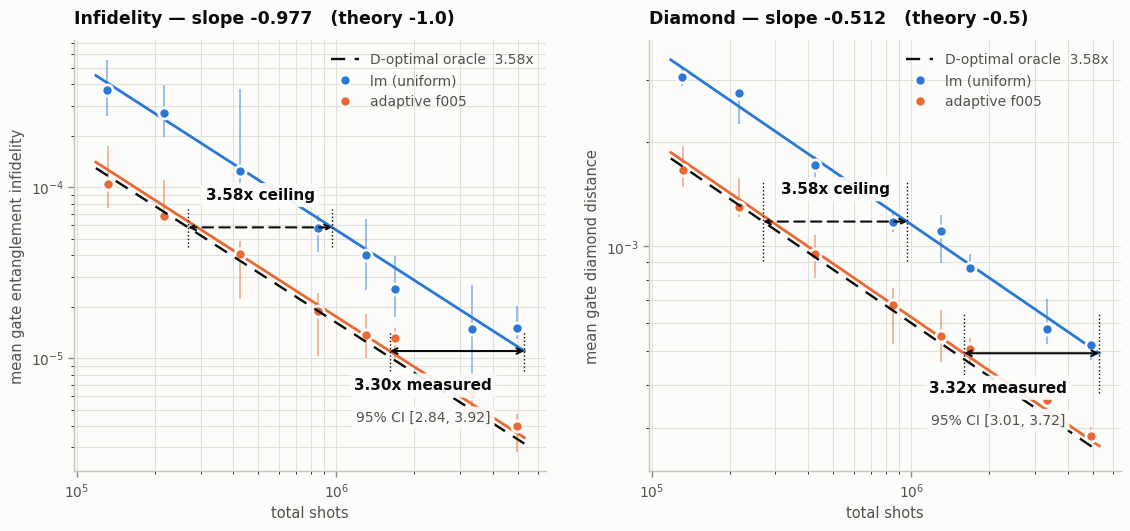

written: /workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments/analytic_ceiling.png


In [30]:
import matplotlib.pyplot as plt

# Palette: slots 1-3 of the validated categorical set (all-pairs clean in both modes).
# Assigned by role and held fixed, so filtering an arm never repaints the others.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
C_LM, C_BEST = "#2a78d6", "#eb6834"

SHOWN = [(BASE_ARM, C_LM, "lm (uniform)"),
         (best, C_BEST, f"adaptive f{best.split('_f')[1]}")]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), facecolor=SURFACE)
fig.subplots_adjust(wspace=0.22)


def dress(ax, xlabel, ylabel, title):
    ax.set_facecolor(SURFACE)
    ax.grid(True, which="both", color=GRID, lw=0.8, ls="-", zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(1.0)
    ax.tick_params(colors=MUTED, labelcolor=INK2, length=4, width=1.0)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10.5)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10.5)
    ax.set_title(title, color=INK, fontsize=12.5, fontweight="semibold",
                 loc="left", pad=12)


for ax, metric, unit in ((axes[0], "infidelity", "mean gate entanglement infidelity"),
                         (axes[1], "diamond", "mean gate diamond distance")):
    a, icpt = FIT[metric]["slope"], FIT[metric]["icpt"]
    xs = np.array(sorted(runs.shots.unique()), dtype=float)
    grid_x = np.geomspace(xs.min(), xs.max(), 100)

    # The ceiling as a LINE. A shot multiplier is a horizontal shift on log-log axes, so the
    # oracle design's curve is lm's fit translated left by d_eff -- i.e. lm's value at
    # d_eff * x. Being a shift, it is metric-independent: the same factor draws it in both
    # panels. No real allocation of the same budget can sit below this line.
    ax.plot(grid_x, np.exp(a * (np.log(grid_x) + np.log(d_eff)) + icpt[BASE_ARM]),
            color=INK, lw=1.7, ls=(0, (6, 4)), zorder=5,
            label=f"D-optimal oracle  {d_eff:.2f}x")

    for arm, colour, label in SHOWN:
        q = runs[runs.arm == arm].dropna(subset=[metric])
        # group on BUDGET: the actual shot counts differ slightly between seeds, so
        # grouping on `shots` would leave one marker per run instead of one per budget
        g = q.groupby("budget").agg(x=("shots", "median"), med=(metric, "median"),
                                    lo=(metric, lambda v: v.quantile(0.25)),
                                    hi=(metric, lambda v: v.quantile(0.75)))
        # spread first, so the markers sit on top of their own whiskers
        ax.vlines(g["x"], g["lo"], g["hi"], color=colour, lw=1.3, alpha=0.5, zorder=2)
        ax.plot(grid_x, np.exp(a * np.log(grid_x) + icpt[arm]), color=colour, lw=2.0,
                zorder=3)
        ax.plot(g["x"], g["med"], "o", ms=8, color=colour, mec=SURFACE, mew=2.0,
                zorder=4, label=label)

    # Both gaps, drawn the same way. Every fit is parallel, so the horizontal distance
    # between two lines is the same at any height -- which means an arrow can be placed
    # wherever it reads best without distorting what it measures. Anchoring each arrow's
    # RIGHT end at a chosen x (rather than a chosen y) keeps both ends on-axis in both
    # panels automatically, since the two panels share an x range but not a y range.
    x_hi = xs.max()
    mult = res[metric][best][0]

    def gap_arrow(x_right, factor, dashed):
        """Draw the arrow spanning the horizontal gap `factor` on lm's fitted line."""
        y = float(np.exp(a * np.log(x_right) + icpt[BASE_ARM]))
        x_left = x_right / factor
        style = dict(arrowstyle="<->", color=INK, lw=1.5, shrinkA=0, shrinkB=0)
        if dashed:
            style["linestyle"] = (0, (5, 3))
        ax.annotate("", xy=(x_left, y), xytext=(x_right, y), arrowprops=style, zorder=6)
        for xe in (x_left, x_right):
            ax.plot([xe, xe], [y / 1.3, y * 1.3], color=INK, lw=1.0, ls=":", zorder=5)
        return y, x_left, x_right

    # ceiling higher and to the left, measured lower and to the right, so the two arrows
    # sit clear of each other and of the marker clouds
    y_ceil, xc_lo, xc_hi = gap_arrow(x_hi / 5.5, d_eff, True)
    y0, x_lo, _ = gap_arrow(x_hi, mult, False)

    ax.set_xscale("log")
    ax.set_yscale("log")
    dress(ax, "total shots", unit,
          f"{metric.capitalize()} — slope {a:+.3f}"
          f"   (theory {-1.0 if metric == 'infidelity' else -0.5:+.1f})")
    # upper right: the only quadrant no series passes through on these axes
    leg = ax.legend(frameon=False, fontsize=10, loc="upper right")
    for t in leg.get_texts():
        t.set_color(INK2)

    # Labels go in AXES coordinates and only now, with the limits settled by the log scales,
    # so each can be clamped away from both edges. Anchored to a data x instead, a wide label
    # overflows the panel -- and the two panels share an x range but not a y range, so a
    # placement that fits one can spill out of the other.
    (xa, xb), (ya, yb) = np.log10(ax.get_xlim()), np.log10(ax.get_ylim())

    def frac(x_left, x_right, y):
        return (float(np.clip((0.5 * (np.log10(x_left) + np.log10(x_right)) - xa) / (xb - xa),
                              0.26, 0.74)),
                (np.log10(y) - ya) / (yb - ya))

    def tag(fx, fy, text, size, colour, weight):
        ax.text(fx, fy, text, transform=ax.transAxes, ha="center", va="center",
                color=colour, fontsize=size, fontweight=weight, zorder=7,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=SURFACE, edgecolor="none",
                          alpha=0.92))

    fxc, fyc = frac(xc_lo, xc_hi, y_ceil)
    tag(fxc, fyc + 0.075, f"{d_eff:.2f}x ceiling", 11, INK, "semibold")

    fxm, fym = frac(x_lo, x_hi, y0)
    lo_m, hi_m = res[metric][best][1], res[metric][best][2]
    tag(fxm, fym - 0.080, f"{mult:.2f}x measured", 11, INK, "semibold")
    tag(fxm, fym - 0.155, f"95% CI [{lo_m:.2f}, {hi_m:.2f}]", 10, INK2, "normal")

fig.savefig(SSE / "analytic_ceiling.png", dpi=170, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()
print(f"written: {SSE / 'analytic_ceiling.png'}")